In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("data.csv")
df.head()
df.shape
df.columns


Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [8]:
X = df['area_mean'].values
y = df['area_worst'].values
print(X.shape)

(569,)


In [4]:

def cost(x,w,y,b):
  m=x.shape[0]
  cost=0
  ypred=np.dot(x,w)+b
  for i in range (m):
    err = (ypred[i]-y[i])**2
    cost += err
  return (cost/(2*m))

In [11]:
def gradient(x,w,y,b):
  m=x.shape[0]
  djw=0
  djb=0
  ypred=np.dot(x,w)+b
  for i in range(m):
    err=(ypred[i]-y[i])
    djw+=err*x[i]
    djb+=err
  return (djw/m,djb/m)

In [15]:
def gradient_descent(x,w,y,b,alpha,iterations):
  costHistory=[]
  for i in range (iterations):
    djw,djb=gradient(x,w,y,b)
    w-= alpha*djw
    b-= alpha*djb
    current_cost=cost(x,w,y,b)
    costHistory.append(current_cost)
    if i%100 ==0:
      print(f"Iteration {i}, Cost = {current_cost}")
  return (w,b,costHistory)

In [7]:
def mse(y_true,y_pred):
  return np.mean((y_true-y_pred)**2)
def r2_score(y_true,y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

In [16]:
alpha = 0.02
iterations = 3000
X_scaled = (X-np.mean(X))/np.std(X)
b = 0
X_train=X_scaled[:450]
X_test=X_scaled[450:]
y_train=y[:450]
y_test=y[450:]
w = 0.0
w, b, costHistory = gradient_descent(X_train, w, y_train, b, alpha, iterations)

Iteration 0, Cost = 543476.9177825567
Iteration 100, Cost = 23610.339764244556
Iteration 200, Cost = 15124.004377104664
Iteration 300, Cost = 14985.444434811468
Iteration 400, Cost = 14983.181524676442
Iteration 500, Cost = 14983.144555673156
Iteration 600, Cost = 14983.143951467295
Iteration 700, Cost = 14983.14394158736
Iteration 800, Cost = 14983.143941425706
Iteration 900, Cost = 14983.14394142305
Iteration 1000, Cost = 14983.143941422972
Iteration 1100, Cost = 14983.143941423012
Iteration 1200, Cost = 14983.14394142301
Iteration 1300, Cost = 14983.143941422988
Iteration 1400, Cost = 14983.143941422999
Iteration 1500, Cost = 14983.143941423014
Iteration 1600, Cost = 14983.143941423019
Iteration 1700, Cost = 14983.14394142301
Iteration 1800, Cost = 14983.14394142301
Iteration 1900, Cost = 14983.14394142301
Iteration 2000, Cost = 14983.14394142301
Iteration 2100, Cost = 14983.14394142301
Iteration 2200, Cost = 14983.14394142301
Iteration 2300, Cost = 14983.14394142301
Iteration 2400,

In [17]:
y_pred = np.dot(X_test, w)+ b
print(w,b)
print("MSE:", mse(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

544.8678782526235 885.8561992282442
MSE: 10461.351883470274
R2: 0.9680123473995919


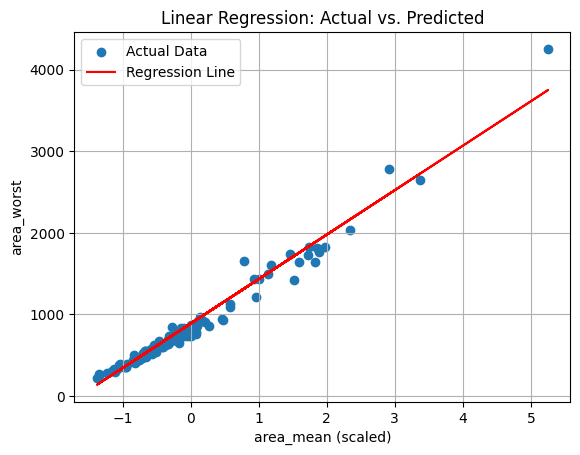

In [18]:
plt.scatter(X_test, y_test, label='Actual Data')
plt.plot(X_test, y_pred, color='red', label='Regression Line')
plt.xlabel('area_mean (scaled)')
plt.ylabel('area_worst')
plt.title('Linear Regression: Actual vs. Predicted')
plt.legend()
plt.grid(True)
plt.show()

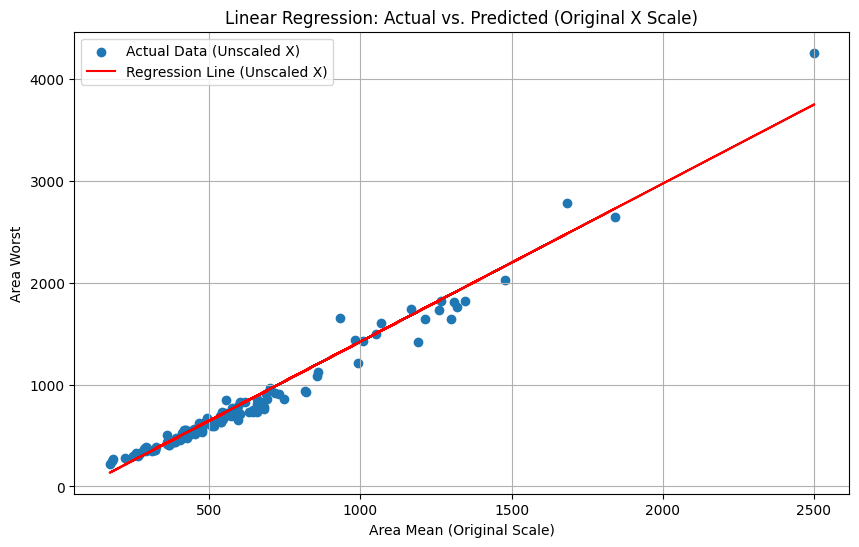

In [20]:
# The model is y = w_scaled * ((x_unscaled - np.mean(X)) / np.std(X)) + b_scaled
# This simplifies to: y = (w_scaled / np.std(X)) * x_unscaled + (b_scaled - (w_scaled * np.mean(X) / np.std(X)))
w_unscaled = w / np.std(X)
b_unscaled = b - (w * np.mean(X) / np.std(X))

X_test_original = X[450:]

y_pred_unscaled = (w_unscaled * X_test_original) + b_unscaled

plt.figure(figsize=(10, 6))
plt.scatter(X_test_original, y_test, label='Actual Data (Unscaled X)')
plt.plot(X_test_original, y_pred_unscaled, color='red', label='Regression Line (Unscaled X)')
plt.xlabel('Area Mean (Original Scale)')
plt.ylabel('Area Worst')
plt.title('Linear Regression: Actual vs. Predicted (Original X Scale)')
plt.legend()
plt.grid(True)
plt.show()